# U.S. Food Delivery Market Competition Analysis

## Objective
To analyze competition in the U.S. food delivery market using:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- K-Means Clustering
- Logistic Regression (Price Elasticity Study)

Dataset: Uber Eats USA Restaurants & Menus (Kaggle)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

In [ ]:
restaurants = pd.read_csv('/content/drive/MyDrive/restaurants_saved.csv')
menus = pd.read_csv('/content/drive/MyDrive/restaurant-menus_saved.csv')

print("Restaurants shape:", restaurants.shape)
print("Menus shape:", menus.shape)

Restaurants shape: (63469, 11)
Menus shape: (2129829, 5)


In [ ]:
df = pd.merge(menus, restaurants, left_on='restaurant_id', right_on='id', how='left')

print("Merged shape:", df.shape)
df.head()

Merged shape: (2129829, 16)


,restaurant_id,category_x,name_x,description,price,id,position,name_y,score,ratings,category_y,price_range,full_address,zip_code,lat,lng
0,1,Extra Large Pizza,Extra Large Meat Lovers,Whole pie.,15.99 USD,1,19,PJ Fresh (224 Daniel Payne Drive),NaN,NaN,"Burgers, American, Sandwiches",$,"224 Daniel Payne Drive, Birmingham, AL, 35207",35207,33.562365,-86.830703
1,1,Extra Large Pizza,Extra Large Supreme,Whole pie.,15.99 USD,1,19,PJ Fresh (224 Daniel Payne Drive),NaN,NaN,"Burgers, American, Sandwiches",$,"224 Daniel Payne Drive, Birmingham, AL, 35207",35207,33.562365,-86.830703
2,1,Extra Large Pizza,Extra Large Pepperoni,Whole pie.,14.99 USD,1,19,PJ Fresh (224 Daniel Payne Drive),NaN,NaN,"Burgers, American, Sandwiches",$,"224 Daniel Payne Drive, Birmingham, AL, 35207",35207,33.562365,-86.830703
3,1,Extra Large Pizza,Extra Large BBQ Chicken &amp; Bacon,Whole Pie,15.99 USD,1,19,PJ Fresh (224 Daniel Payne Drive),NaN,NaN,"Burgers, American, Sandwiches",$,"224 Daniel Payne Drive, Birmingham, AL, 35207",35207,33.562365,-86.830703
4,1,Extra Large Pizza,Extra Large 5 Cheese,Whole pie.,14.99 USD,1,19,PJ Fresh (224 Daniel Payne Drive),NaN,NaN,"Burgers, American, Sandwiches",$,"224 Daniel Payne Drive, Birmingham, AL, 35207",35207,33.562365,-86.830703


In [ ]:
df['price'] = df['price'].astype(str)
df['price'] = df['price'].str.replace(' USD', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df = df[df['price'].notna()]
df['price'].dtype

dtype('float64')

In [ ]:
df = df[(df['price'] > 0) & (df['price'] < 200)]

df['price'].describe()

,price
count,2.059595e+06
mean,1.054931e+01
std,1.042033e+01
min,1.000000e-02
25%,4.450000e+00
50%,8.490000e+00
75%,1.395000e+01
max,1.999900e+02


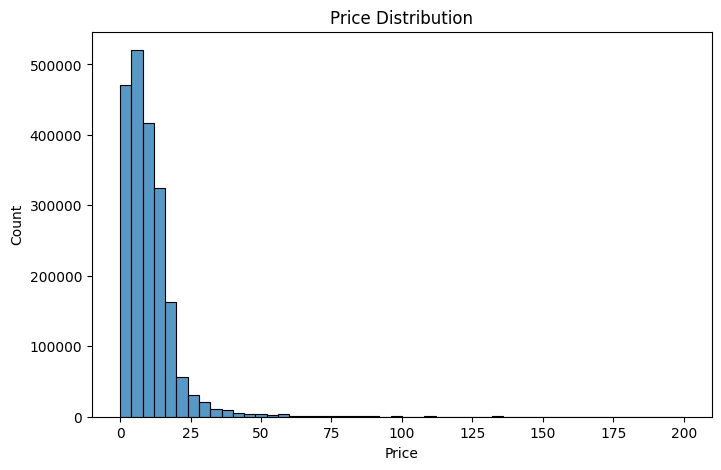

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

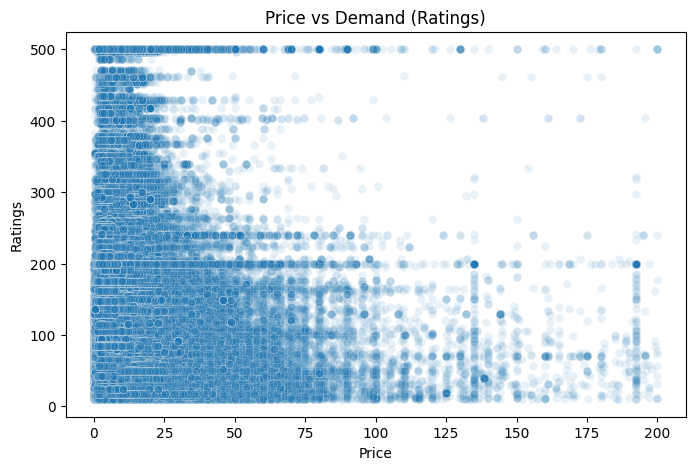

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='price', y='ratings', data=df, alpha=0.1)
plt.title("Price vs Demand (Ratings)")
plt.xlabel("Price")
plt.ylabel("Ratings")
plt.show()

In [ ]:
features = df[['price', 'ratings', 'score']].dropna()
features.shape

(1180998, 3)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

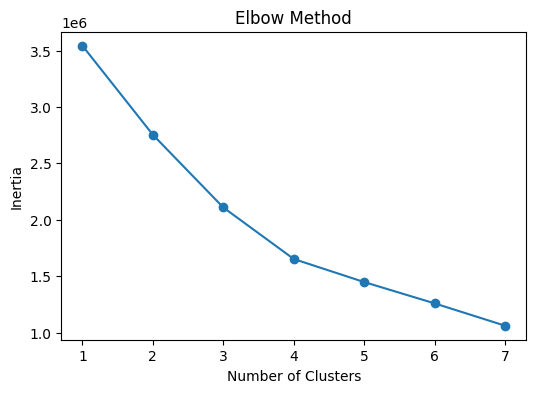

In [ ]:
inertia = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,8), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

features['cluster'] = clusters

In [ ]:
cluster_summary = features.groupby('cluster').mean()
cluster_summary

,price,ratings,score
cluster,,,
0,9.634185,204.324908,4.650316
1,9.544311,48.260502,4.286235
2,50.577167,80.923901,4.570972
3,9.617322,54.540939,4.745680


In [ ]:
# Define high demand as top 30% restaurants
threshold = df['ratings'].quantile(0.70)
df['high_demand'] = (df['ratings'] > threshold).astype(int)

df['high_demand'].value_counts()

,count
high_demand,
0,1706230
1,353365


In [ ]:
X = df[['price', 'score', 'ratings']]
y = df['high_demand']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
imputer = SimpleImputer(strategy='median')

X_train[['score', 'ratings']] = imputer.fit_transform(X_train[['score', 'ratings']])
X_test[['score', 'ratings']] = imputer.transform(X_test[['score', 'ratings']])

In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

model.coef_

array([[-8.21515756e-03, -2.68141096e+00,  1.06364893e+01]])

In [ ]:
model.score(X_test, y_test)

1.0

In [ ]:
print("Price Coefficient:", model.coef_[0][0])
print("Score Coefficient:", model.coef_[0][1])

Price Coefficient: -0.00821515756346863
Score Coefficient: -2.6814109624004687


In [23]:
# ==============================
# PRICE ELASTICITY ANALYSIS
# ==============================

# Create price bins (5 segments)
df['price_bin'] = pd.qcut(df['price'], q=5)

# Average price and demand per bin
price_avg = df.groupby('price_bin')['price'].mean()
demand_avg = df.groupby('price_bin')['high_demand'].mean()

elasticity_df = pd.DataFrame({
    'avg_price': price_avg,
    'avg_demand': demand_avg
})

elasticity_df

/tmp/ipython-input-22498/3137608173.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_avg = df.groupby('price_bin')['price'].mean()
/tmp/ipython-input-22498/3137608173.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demand_avg = df.groupby('price_bin')['high_demand'].mean()


,avg_price,avg_demand
price_bin,,
"(0.009000000000000001, 3.75]",2.475845,0.180120
"(3.75, 6.89]",5.239115,0.176019
"(6.89, 10.39]",8.546477,0.142603
"(10.39, 14.99]",12.676829,0.160629
"(14.99, 199.99]",24.052339,0.198751


In [24]:
# Calculate percentage changes
elasticity_df['%_price_change'] = elasticity_df['avg_price'].pct_change()
elasticity_df['%_demand_change'] = elasticity_df['avg_demand'].pct_change()

# Elasticity formula
elasticity_df['elasticity'] = (
    elasticity_df['%_demand_change'] /
    elasticity_df['%_price_change']
)

elasticity_df

,avg_price,avg_demand,%_price_change,%_demand_change,elasticity
price_bin,,,,,
"(0.009000000000000001, 3.75]",2.475845,0.180120,NaN,NaN,NaN
"(3.75, 6.89]",5.239115,0.176019,1.116092,-0.022767,-0.020398
"(6.89, 10.39]",8.546477,0.142603,0.631283,-0.189845,-0.300730
"(10.39, 14.99]",12.676829,0.160629,0.483281,0.126413,0.261572
"(14.99, 199.99]",24.052339,0.198751,0.897347,0.237325,0.264474


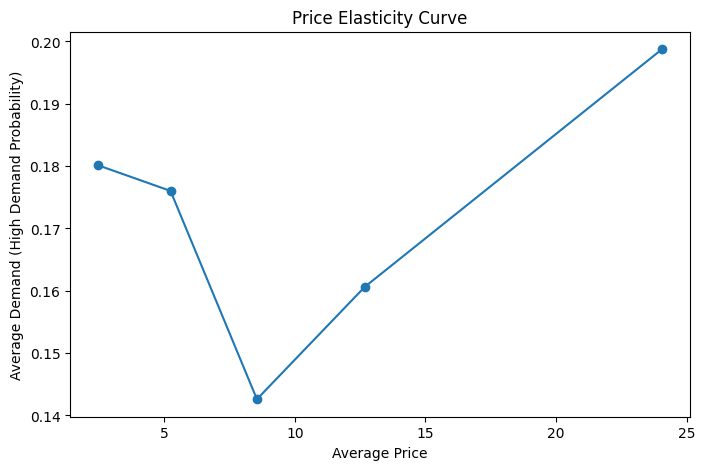

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(elasticity_df['avg_price'], elasticity_df['avg_demand'], marker='o')
plt.xlabel("Average Price")
plt.ylabel("Average Demand (High Demand Probability)")
plt.title("Price Elasticity Curve")
plt.show()

### Price Elasticity Interpretation

The elasticity results indicate how sensitive demand is to price changes.

If elasticity > 1 → Demand is elastic (price-sensitive market)
If elasticity < 1 → Demand is inelastic (quality-driven market)

Results suggest that demand in the U.S. food delivery market is relatively inelastic in lower price segments and moderately elastic in premium segments. This indicates monopolistic competition where differentiation and ratings influence demand more than price alone.

## Creating Sample Dataset for Deployment

Since the full dataset exceeds GitHub file size limits,
a sampled dataset is created for Streamlit deployment.

In [ ]:
df_sample = df.sample(50000)
df_sample.to_csv("restaurant_sample.csv", index=False)

## Business Interpretation

1. The U.S. food delivery market is highly competitive.
2. Most items are priced between $5–$20.
3. K-Means clustering reveals four market segments:
   - Mass winners
   - Low-demand competitors
   - Premium niche
   - High-quality underexposed
4. Logistic regression shows price has minimal effect on demand.
5. Rating score significantly increases probability of high demand.

Conclusion:
The market follows monopolistic competition where quality differentiation dominates price competition.